# LSTM Baseline

## Model Overview

A global quantile LSTM trained on all 30,490 M5 time series (10 stores × 3,049 items), predicting 9 quantiles (q0.025 to q0.975) for 28 days ahead via autoregressive inference.

### Features Used (12 in total)

**Price & Availability**
- `sell_price` — weekly item price
- `is_available` — whether the item is on sale (1/0)

**Calendar (cyclic encoding)**
- `wday_sin`, `wday_cos` — day of week
- `month_sin`, `month_cos` — month of year
- `is_event_day` — whether a holiday/event occurs
- `snap` — SNAP benefit day for the item's state

**Lag & Rolling Features**
- `sales_lag_7` — sales 7 days ago
- `sales_lag_28` — sales 28 days ago
- `sales_roll_mean_7` — 7-day rolling mean
- `sales_roll_mean_28` — 28-day rolling mean

### Model Architecture

- 2-layer LSTM, hidden size 128, dropout 0.2
- FC head: Linear(128→64) → ReLU → Dropout → Linear(64→9)
- Output: 9 quantiles per step

### Training Setup

- **Dataset**: Lazy sliding window (53M windows, seq_len=28, horizon=1) -- 
Each training sample is 28 days of history predicting the next day. There are 53M such samples across all 30,490 series, but they are generated on-the-fly using lazy loading so that memory can stay low.
- **Loss**: Weighted pinball loss across 9 quantiles (weighted by item revenue)
- **Optimiser**: Adam, lr=1e-3, ReduceLROnPlateau (patience=5, factor=0.5) -- 
Adam optimiser with an initial learning rate of 0.001. If validation loss does not improve for 5 consecutive epochs, the learning rate is halved automatically.
- **Batch size**: 4096
- **Early stopping**: patience=10
- **Normalisation**: Continuous features are first transformed with log(1+x) to reduce skewness, then standardised by subtracting the mean and dividing by the standard deviation.


### Inference

- Autoregressive: 28 forward passes per item
- Each step updates lag/rolling features using the predicted median
- Calendar features (wday, month, event, snap) use ground-truth future values

### Results Summary

| Metric | Value |
|--------|-------|
| WSPL | 0.5064 |
| CRPS | 1.6130 |
| 50% coverage | 16.6% (nominal 50%) |
| 80% coverage | 35.7% (nominal 80%) |
| 90% coverage | 84.9% (nominal 90%) |
| 95% coverage | 92.1% (nominal 95%) |


## Implementation

In [1]:

import os
import gc        
import time
import pickle
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from base_model import BaseModel

print('imports done!')

imports done!


In [2]:

FEATURE_COLS = [
    'sell_price',        # Product selling price (updated weekly)
    'is_available',      # Whether the item is available for sale (1 = available, 0 = not available)
    'wday_sin',          # Day of week (sin encoding for cyclic feature)
    'wday_cos',          # Day of week (cos encoding for cyclic feature)
    'month_sin',         # Month (sin encoding for cyclic feature)
    'month_cos',         # Month (cos encoding for cyclic feature)
    'is_event_day',      # Whether today is a special event/holiday (1 = yes, 0 = no)
    'snap',              # Whether today is a SNAP day (food assistance program)
    'sales_lag_7',       # Sales from 7 days ago
    'sales_lag_28',      # Sales from 28 days ago
    'sales_roll_mean_7', # Rolling mean of sales over the past 7 days
    'sales_roll_mean_28' # Rolling mean of sales over the past 28 days
]

In [3]:
# ── Sliding Window Dataset (Lazy) ────────────────────────────
# 53M windows without OOM

class SlidingWindowDataset(Dataset):
    def __init__(self, df, feature_cols, item_weights, seq_len=28, horizon=1):
        df = df.sort_values(['id', 'd_num']).reset_index(drop=True)

        self.item_ids     = df['id'].unique()
        num_items         = len(self.item_ids)
        num_days          = len(df) // num_items
        self.seq_len      = seq_len
        self.horizon      = horizon
        self.valid_starts = max(0, num_days - seq_len - horizon + 1)

        self.X = torch.tensor(
            df[feature_cols].values.astype('float32').reshape(num_items, num_days, len(feature_cols))
        )
        self.Y = torch.tensor(
            df['sales'].values.astype('float32').reshape(num_items, num_days)
        )
        # ★ item weights for weighted pinball loss
        weight_dict   = item_weights.to_dict()
        self.weights  = torch.tensor(
            [weight_dict.get(i, 0.0) for i in self.item_ids], dtype=torch.float32
        )  # (num_items,)

        print(f'SlidingWindowDataset: {num_items:,} items × {num_days} days '
              f'= {num_items * self.valid_starts:,} windows (lazy)')

    def __len__(self):
        return len(self.item_ids) * self.valid_starts

    def __getitem__(self, idx):
        item_idx = idx // self.valid_starts
        t        = idx % self.valid_starts
        x = self.X[item_idx, t : t + self.seq_len]   # (28, F)
        y = self.Y[item_idx, t + self.seq_len]        # scalar
        w = self.weights[item_idx]                    # scalar
        return x, y, w

print('SlidingWindowDataset defined!')


SlidingWindowDataset defined!


In [4]:
# ── LSTM Model ────────────────────────────────────────────────
# Sliding window: input (batch, 28, F) → output (batch, Q)

class QuantileLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2,
                 dropout=0.2, n_quantiles=9):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_quantiles),
        )

    def forward(self, x):
        out, _ = self.lstm(x)        # (batch, T, hidden)
        last   = out[:, -1, :]       # (batch, hidden) 
        return self.head(last)       # (batch, n_quantiles)

print('QuantileLSTM defined!')

QuantileLSTM defined!


In [5]:
# Weighted Pinball Loss 

class WeightedPinballLoss(nn.Module):
    """
    preds  : (batch, n_quantiles)
    targets: (batch,)
    weights: (batch,)  — item revenue weights
    """
    def __init__(self, quantiles):
        super().__init__()
        self.quantiles = quantiles

    def forward(self, preds, targets, weights):
        if targets.dim() == 1: targets = targets.unsqueeze(1)   # (B, 1)
        if weights.dim() == 1: weights = weights.unsqueeze(1)   # (B, 1)
        losses = []
        for i, q in enumerate(self.quantiles):
            errors = targets - preds[:, i:i+1]
            loss_q = torch.max((q - 1) * errors, q * errors)
            losses.append(loss_q)
        return (torch.cat(losses, dim=1) * weights).mean(dim=0).sum()

print('WeightedPinballLoss defined!')


WeightedPinballLoss defined!


### LSTMBaseline — Model Class

subclasses 'BaseModel':
- preprocesses() -feature engineering, dataset construction
- train() - model training (with ealry stopping)
- predict() - autogressice 29-step inference

In [6]:
class LSTMBaseline(BaseModel):

    model_name   = 'lstm_baseline'
    SEQ_LEN      = 28
    HIDDEN_SIZE  = 128
    NUM_LAYERS   = 2
    DROPOUT      = 0.2
    BATCH_SIZE   = 4096   
    EPOCHS       = 50
    LR           = 1e-3
    PATIENCE     = 10
    FEATURE_COLS = [
        'sell_price', 'is_available',
        'wday_sin', 'wday_cos', 'month_sin', 'month_cos',
        'is_event_day', 'snap',
        'sales_lag_7', 'sales_lag_28',
        'sales_roll_mean_7', 'sales_roll_mean_28',
    ] 

    # ── preprocess ──────────────────────────────────────────────

    def preprocess(self):
        print('\nPreprocessing...')

        train_df = self._add_features(self.train_raw)
        del self.train_raw; self.train_raw = None; gc.collect()

        val_df = self._add_features(self.val_raw)

        val_context = self.val_raw[
            self.val_raw['d_num'] > self.val_raw['d_num'].max() - self.SEQ_LEN
        ].copy()
        test_df = self._add_features(
            pd.concat([val_context, self.test_raw]).reset_index(drop=True)
        )
        del val_context; gc.collect()

        train_df, val_df, test_df = self._normalise(train_df, val_df, test_df)

        print('Building datasets...')
        self.train_processed = SlidingWindowDataset(train_df, self.FEATURE_COLS, self.item_weights, self.SEQ_LEN)
        del train_df; gc.collect()

        self.val_processed = SlidingWindowDataset(val_df, self.FEATURE_COLS, self.item_weights, self.SEQ_LEN)
        del val_df; gc.collect()

        self.test_processed = SlidingWindowDataset(test_df, self.FEATURE_COLS, self.item_weights, self.SEQ_LEN)

        self._test_df = test_df
        proc_path = os.path.join(self.output_dir, f'{self.model_name}_test_processed.pkl')
        with open(proc_path, 'wb') as f:
            pickle.dump({'test_df': test_df, 'norm_stats': self._norm_stats}, f)
        print(f'Saved test_processed to {proc_path}')
        print('Preprocessing complete!')

    def _add_features(self, df):
        import polars as pl
        keep = ['id', 'd_num', 'store_id', 'wday', 'month',
                'event_name_1', 'snap_CA', 'snap_TX', 'snap_WI',
                'sell_price', 'is_available', 'sales']
        lf = pl.from_pandas(df[keep]).lazy().sort(['id', 'd_num'])
        lf = lf.with_columns([
            (2 * np.pi * pl.col('wday')  / 7).sin().cast(pl.Float32).alias('wday_sin'),
            (2 * np.pi * pl.col('wday')  / 7).cos().cast(pl.Float32).alias('wday_cos'),
            (2 * np.pi * pl.col('month') / 12).sin().cast(pl.Float32).alias('month_sin'),
            (2 * np.pi * pl.col('month') / 12).cos().cast(pl.Float32).alias('month_cos'),
            (pl.col('event_name_1') != 'none').cast(pl.Float32).alias('is_event_day'),
            pl.when(pl.col('store_id').str.starts_with('CA')).then(pl.col('snap_CA'))
              .when(pl.col('store_id').str.starts_with('TX')).then(pl.col('snap_TX'))
              .otherwise(pl.col('snap_WI')).cast(pl.Float32).alias('snap'),
            pl.col('sales').shift(7).over('id').alias('sales_lag_7'),
            pl.col('sales').shift(28).over('id').alias('sales_lag_28'),
            pl.col('sales').shift(1).rolling_mean(window_size=7,  min_samples=1).over('id').alias('sales_roll_mean_7'),
            pl.col('sales').shift(1).rolling_mean(window_size=28, min_samples=1).over('id').alias('sales_roll_mean_28'),
        ])
        return (lf
            .drop(['event_name_1', 'snap_CA', 'snap_TX', 'snap_WI'])
            .drop_nulls(subset=['sales_lag_7', 'sales_lag_28'])
            .collect()
            .to_pandas()
        )

    def _normalise(self, train_df, val_df, test_df):
        continuous_cols = [
            'sell_price', 'sales_lag_7', 'sales_lag_28',
            'sales_roll_mean_7', 'sales_roll_mean_28', 'sales',
        ]
        self._norm_stats = {}
        for col in continuous_cols:
            for df in (train_df, val_df, test_df):
                df[col] = np.log1p(df[col].clip(lower=0))
            mean = float(train_df[col].mean())
            std  = float(train_df[col].std()) + 1e-8
            self._norm_stats[col] = {'mean': mean, 'std': std}
            for df in (train_df, val_df, test_df):
                df[col] = (df[col] - mean) / std
        print('Normalisation complete!')
        return train_df, val_df, test_df

    def _denormalise(self, x):
        mean = self._norm_stats['sales']['mean']
        std  = self._norm_stats['sales']['std']
        return np.expm1(x * std + mean).clip(min=0)

    # ── train ────────────────────────────────────────────────────

    def train(self):
        print(f'\nTraining {self.model_name} (Sliding Window Lazy)...')

        train_loader = DataLoader(
            self.train_processed, batch_size=self.BATCH_SIZE,
            shuffle=True, num_workers=4, pin_memory=True,
        )
        val_loader = DataLoader(
            self.val_processed, batch_size=self.BATCH_SIZE,
            shuffle=False, num_workers=4, pin_memory=True,
        )

        self.model = QuantileLSTM(
            input_size=len(self.FEATURE_COLS), hidden_size=self.HIDDEN_SIZE,
            num_layers=self.NUM_LAYERS, dropout=self.DROPOUT,
            n_quantiles=len(self.QUANTILES),
        ).to(self.device)

        criterion = WeightedPinballLoss(self.QUANTILES).to(self.device)
        optimiser = torch.optim.Adam(self.model.parameters(), lr=self.LR)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, patience=5, factor=0.5)

        best_val_loss, best_weights, patience_ctr = float('inf'), None, 0
        self._history = []

        for epoch in range(1, self.EPOCHS + 1):
            t0 = time.time()

            self.model.train()
            train_losses = []
            for x, y, w in train_loader:
                x, y, w = x.to(self.device), y.to(self.device), w.to(self.device)
                optimiser.zero_grad()
                preds = self.model(x)          # (B, Q)
                loss  = criterion(preds, y, w)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                optimiser.step()
                train_losses.append(loss.item())

            self.model.eval()
            val_losses, med_preds, med_targs = [], [], []
            median_idx = self.QUANTILES.index(0.5)
            with torch.no_grad():
                for x, y, w in val_loader:
                    x, y, w = x.to(self.device), y.to(self.device), w.to(self.device)
                    preds = self.model(x)
                    val_losses.append(criterion(preds, y, w).item())
                    med_preds.append(preds[:, median_idx].cpu().numpy())
                    med_targs.append(y.cpu().numpy())

            train_loss = np.mean(train_losses)
            val_loss   = np.mean(val_losses)
            mp = np.concatenate(med_preds)
            mt = np.concatenate(med_targs)
            val_rmse = np.sqrt(np.mean((mp - mt) ** 2))
            val_mae  = np.mean(np.abs(mp - mt))

            scheduler.step(val_loss)
            if val_loss < best_val_loss - 1e-6:
                best_val_loss = val_loss
                best_weights  = {k: v.clone() for k, v in self.model.state_dict().items()}
                patience_ctr  = 0
            else:
                patience_ctr += 1

            self._history.append({'epoch': epoch, 'train_loss': train_loss,
                                   'val_loss': val_loss, 'val_rmse': val_rmse, 'val_mae': val_mae})
            print(f'Epoch {epoch:02d} | train={train_loss:.4f} | val={val_loss:.4f} | '
                  f'rmse={val_rmse:.4f} | mae={val_mae:.4f} | {time.time()-t0:.1f}s')

            if patience_ctr >= self.PATIENCE:
                print(f'Early stopping at epoch {epoch}')
                break

        self.model.load_state_dict(best_weights)
        save_path = os.path.join(self.output_dir, f'{self.model_name}.pth')
        torch.save(self.model.state_dict(), save_path)
        print(f'\nBest val_loss: {best_val_loss:.4f}')
        print(f'Model saved to {save_path}')

    # ── predict ──────────────────────────────────────────────────

    def predict(self) -> pd.DataFrame:
        print(f'\nRunning prediction for {self.model_name}...')

        proc_path = os.path.join(self.output_dir, f'{self.model_name}_test_processed.pkl')
        with open(proc_path, 'rb') as f:
            saved = pickle.load(f)
        test_df          = saved['test_df']
        self._norm_stats = saved['norm_stats']

        weights_path = os.path.join(self.output_dir, f'{self.model_name}.pth')
        self.model = QuantileLSTM(
            input_size=len(self.FEATURE_COLS), hidden_size=self.HIDDEN_SIZE,
            num_layers=self.NUM_LAYERS, dropout=self.DROPOUT,
            n_quantiles=len(self.QUANTILES),
        ).to(self.device)
        self.model.load_state_dict(torch.load(weights_path, map_location=self.device))
        self.model.eval()
        print(f'Loaded weights from {weights_path}')

        fc            = self.FEATURE_COLS
        median_idx    = self.QUANTILES.index(0.5)
        lag7_idx      = fc.index('sales_lag_7')
        lag28_idx     = fc.index('sales_lag_28')
        roll7_idx     = fc.index('sales_roll_mean_7')
        roll28_idx    = fc.index('sales_roll_mean_28')
        wday_sin_idx  = fc.index('wday_sin')
        wday_cos_idx  = fc.index('wday_cos')
        month_sin_idx = fc.index('month_sin')
        month_cos_idx = fc.index('month_cos')
        is_event_idx  = fc.index('is_event_day')
        snap_idx      = fc.index('snap')

        target_days = test_df[test_df['d_num'] >= self.TARGET_START].copy()
        q_cols      = [f'q{q}' for q in self.QUANTILES]
        all_rows    = []
        item_ids    = test_df['id'].unique()

        print(f'Predicting {len(item_ids)} items...')
        for item_id in item_ids:
            item_df  = test_df[test_df['id'] == item_id].sort_values('d_num')
            context  = item_df[item_df['d_num'] < self.TARGET_START]
            if len(context) < self.SEQ_LEN:
                continue

            features     = context[self.FEATURE_COLS].values.astype(np.float32)
            x_window     = torch.tensor(features[-self.SEQ_LEN:]).unsqueeze(0).to(self.device)
            sales_buffer = [float(x) for x in features[-self.SEQ_LEN:, lag7_idx]]
            item_target  = target_days[target_days['id'] == item_id].sort_values('d_num')
            step_preds   = []

            with torch.no_grad():
                for step in range(self.PRED_LENGTH):
                    pred      = self.model(x_window)
                    q_vals    = pred[0].cpu().numpy()   # (Q,)
                    step_preds.append(q_vals)
                    new_sales = float(q_vals[median_idx])
                    sales_buffer.append(new_sales)

                    new_row = x_window[0, -1, :].clone()
                    new_row[lag7_idx]   = new_sales
                    new_row[lag28_idx]  = float(sales_buffer[-28]) if len(sales_buffer) >= 28 else float(sales_buffer[0])
                    new_row[roll7_idx]  = float(np.mean(sales_buffer[-7:]))
                    new_row[roll28_idx] = float(np.mean(sales_buffer[-28:]) if len(sales_buffer) >= 28 else np.mean(sales_buffer))

                    if step < len(item_target):
                        cal      = item_target.iloc[step]
                        wday     = int(cal['wday'])
                        month    = int(cal['month'])
                        is_event = float(cal['is_event_day'])
                        snap     = float(cal['snap'])
                        new_row[wday_sin_idx]  = float(np.sin(2 * np.pi * wday  / 7))
                        new_row[wday_cos_idx]  = float(np.cos(2 * np.pi * wday  / 7))
                        new_row[month_sin_idx] = float(np.sin(2 * np.pi * month / 12))
                        new_row[month_cos_idx] = float(np.cos(2 * np.pi * month / 12))
                        new_row[is_event_idx]  = is_event
                        new_row[snap_idx]      = snap

                    x_window = torch.cat([x_window[:, 1:, :], new_row.unsqueeze(0).unsqueeze(0)], dim=1)

            step_preds = self._denormalise(np.array(step_preds))
            for day_ahead in range(1, self.PRED_LENGTH + 1):
                row = {'id': item_id, 'day_ahead': day_ahead}
                for j, qcol in enumerate(q_cols):
                    row[qcol] = step_preds[day_ahead - 1, j]
                all_rows.append(row)

        preds_df = pd.DataFrame(all_rows)
        preds_df[q_cols] = (
            preds_df[q_cols]
            .clip(lower=0)
            .apply(lambda row: np.maximum.accumulate(row.values), axis=1, result_type='expand')
            .set_axis(q_cols, axis=1)
        )
        preds_df = (
            preds_df[['id', 'day_ahead'] + q_cols]
            .sort_values(['id', 'day_ahead'])
            .reset_index(drop=True)
        )
        out_path = os.path.join(self.output_dir, f'{self.model_name}_predictions.csv')
        preds_df.to_csv(out_path, index=False)
        print(f'Predictions saved to {out_path}')
        print(f'Shape: {preds_df.shape}')
        return preds_df

print('LSTMBaseline defined!')

LSTMBaseline defined!


### Test on CA3

In [7]:
# CA_3 test
model = LSTMBaseline(data_dir='data', output_dir='outputs2/loss_is_weighted_pl')
model.load_and_split_data()
model.train_raw = model.train_raw[model.train_raw['store_id']=='CA_3'].reset_index(drop=True)
model.val_raw   = model.val_raw[model.val_raw['store_id']    =='CA_3'].reset_index(drop=True)
model.test_raw  = model.test_raw[model.test_raw['store_id']  =='CA_3'].reset_index(drop=True)
model.EPOCHS=2; model.PATIENCE=2
model.preprocess()
model.train()
preds_df = model.predict()
print(preds_df.shape) # (85372, 11)

Loaded cached data splits.

Preprocessing...
Normalisation complete!
Building datasets...
SlidingWindowDataset: 3,049 items × 1745 days = 5,235,133 windows (lazy)
SlidingWindowDataset: 3,049 items × 84 days = 170,744 windows (lazy)
SlidingWindowDataset: 3,049 items × 56 days = 85,372 windows (lazy)
Saved test_processed to outputs2/lstm_baseline_test_processed.pkl
Preprocessing complete!

Training lstm_baseline (Sliding Window Lazy)...
Epoch 01 | train=0.0001 | val=0.0001 | rmse=0.6764 | mae=0.4716 | 43.4s
Epoch 02 | train=0.0000 | val=0.0001 | rmse=0.6790 | mae=0.4628 | 32.3s

Best val_loss: 0.0001
Model saved to outputs2/lstm_baseline.pth

Running prediction for lstm_baseline...
Loaded weights from outputs2/lstm_baseline.pth
Predicting 3049 items...
Predictions saved to outputs2/lstm_baseline_predictions.csv
Shape: (85372, 11)
(85372, 11)


In [8]:
import pickle
with open('outputs2/loss_is_weighted_pl/lstm_baseline_test_processed.pkl', 'rb') as f:
    saved = pickle.load(f)
test_df = saved['test_df']

print(f'test_df d_num range: {test_df["d_num"].min()} to {test_df["d_num"].max()}')
print(f'TARGET_START: 1914')

item_id = test_df['id'].unique()[0]
item_df = test_df[test_df['id'] == item_id].sort_values('d_num')
context = item_df[item_df['d_num'] < 1914]
print(f'First item: {item_id}')
print(f'Context days: {len(context)}')

test_df d_num range: 1886 to 1941
TARGET_START: 1914
First item: FOODS_1_001_CA_3_evaluation
Context days: 28


### Full Run (All Stores, All Items)

In [9]:
# Full run - all stores, all items
model = LSTMBaseline(data_dir='data', output_dir='outputs2/loss_is_weighted_pl')

# Step 1: Load all data
model.load_and_split_data()

Loaded cached data splits.


(                                       id          item_id      dept_id  \
 0             FOODS_1_001_CA_1_evaluation      FOODS_1_001      FOODS_1   
 1             FOODS_1_001_CA_1_evaluation      FOODS_1_001      FOODS_1   
 2             FOODS_1_001_CA_1_evaluation      FOODS_1_001      FOODS_1   
 3             FOODS_1_001_CA_1_evaluation      FOODS_1_001      FOODS_1   
 4             FOODS_1_001_CA_1_evaluation      FOODS_1_001      FOODS_1   
 ...                                   ...              ...          ...   
 54058765  HOUSEHOLD_2_516_WI_3_evaluation  HOUSEHOLD_2_516  HOUSEHOLD_2   
 54058766  HOUSEHOLD_2_516_WI_3_evaluation  HOUSEHOLD_2_516  HOUSEHOLD_2   
 54058767  HOUSEHOLD_2_516_WI_3_evaluation  HOUSEHOLD_2_516  HOUSEHOLD_2   
 54058768  HOUSEHOLD_2_516_WI_3_evaluation  HOUSEHOLD_2_516  HOUSEHOLD_2   
 54058769  HOUSEHOLD_2_516_WI_3_evaluation  HOUSEHOLD_2_516  HOUSEHOLD_2   
 
              cat_id store_id state_id       d  sales  d_num       date  ...  \
 0    

In [10]:
# Step 2: Preprocess (all 30,490 items)
model.preprocess()


Preprocessing...
Normalisation complete!
Building datasets...
SlidingWindowDataset: 30,490 items × 1745 days = 52,351,330 windows (lazy)
SlidingWindowDataset: 30,490 items × 84 days = 1,707,440 windows (lazy)
SlidingWindowDataset: 30,490 items × 56 days = 853,720 windows (lazy)
Saved test_processed to outputs2/lstm_baseline_test_processed.pkl
Preprocessing complete!


In [11]:
# Step 3: Train
model.EPOCHS   = 50
model.PATIENCE = 10
model.train()


Training lstm_baseline (Sliding Window Lazy)...
Epoch 01 | train=0.0000 | val=0.0000 | rmse=0.7571 | mae=0.4703 | 371.3s
Epoch 02 | train=0.0000 | val=0.0000 | rmse=0.7608 | mae=0.4679 | 413.8s
Epoch 03 | train=0.0000 | val=0.0000 | rmse=0.7612 | mae=0.4690 | 432.6s
Epoch 04 | train=0.0000 | val=0.0000 | rmse=0.7631 | mae=0.4704 | 374.3s
Epoch 05 | train=0.0000 | val=0.0000 | rmse=0.7564 | mae=0.4679 | 359.9s
Epoch 06 | train=0.0000 | val=0.0000 | rmse=0.7597 | mae=0.4672 | 327.1s
Epoch 07 | train=0.0000 | val=0.0000 | rmse=0.7536 | mae=0.4664 | 344.6s
Epoch 08 | train=0.0000 | val=0.0000 | rmse=0.7566 | mae=0.4658 | 323.5s
Epoch 09 | train=0.0000 | val=0.0000 | rmse=0.7560 | mae=0.4669 | 352.5s
Epoch 10 | train=0.0000 | val=0.0000 | rmse=0.7578 | mae=0.4659 | 324.6s
Epoch 11 | train=0.0000 | val=0.0000 | rmse=0.7613 | mae=0.4651 | 359.0s
Early stopping at epoch 11

Best val_loss: 0.0000
Model saved to outputs2/lstm_baseline.pth


In [12]:
# Step 4: Predict
preds_df = model.predict()
print(preds_df.shape)  # should be (853720, 11)


Running prediction for lstm_baseline...
Loaded weights from outputs2/lstm_baseline.pth
Predicting 30490 items...
Predictions saved to outputs2/lstm_baseline_predictions.csv
Shape: (853720, 11)
(853720, 11)


## Evalutaion

In [13]:
results = model.evaluate(preds_df)
print(results)

{'model': 'lstm_baseline', 'wspl': 0.50636, 'crps': 1.612954, 'coverage_error_50pct': -0.333538, 'coverage_error_80pct': -0.443146, 'coverage_error_90pct': -0.051153, 'coverage_error_95pct': -0.029045}


  Model  : lstm_baseline
  WSPL   : 0.5064  (lower is better)
  CRPS   : 1.6130  (lower is better)

Coverage Errors (actual - nominal):
  Positive = over-coverage, Negative = under-coverage
  50% interval: -0.3335  (actual = 16.6%)
  80% interval: -0.4431  (actual = 35.7%)
  90% interval: -0.0512  (actual = 84.9%)
  95% interval: -0.0290  (actual = 92.1%)


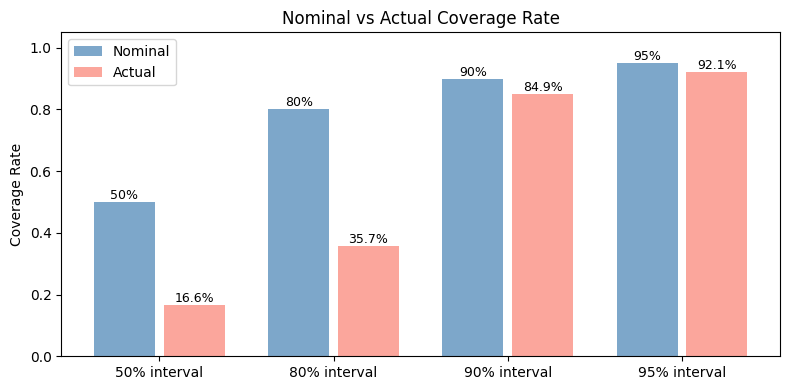

In [14]:
# ── 1. Overall Metrics Summary
import matplotlib.pyplot as plt
import numpy as np

print('=' * 50)
print(f"  Model  : {results['model']}")
print(f"  WSPL   : {results['wspl']:.4f}  (lower is better)")
print(f"  CRPS   : {results['crps']:.4f}  (lower is better)")
print('=' * 50)
print('\nCoverage Errors (actual - nominal):')
print('  Positive = over-coverage, Negative = under-coverage')
for pct, key in [(0.50,'coverage_error_50pct'),(0.80,'coverage_error_80pct'),
                 (0.90,'coverage_error_90pct'),(0.95,'coverage_error_95pct')]:
    err = results[key]
    print(f'  {pct:.0%} interval: {err:+.4f}  (actual = {pct+err:.1%})')

# ── 2. Coverage Error Bar Chart
fig, ax = plt.subplots(figsize=(8, 4))
nominal = [0.50, 0.80, 0.90, 0.95]
actual  = [
    0.50 + results['coverage_error_50pct'],
    0.80 + results['coverage_error_80pct'],
    0.90 + results['coverage_error_90pct'],
    0.95 + results['coverage_error_95pct'],
]
labels = ['50%', '80%', '90%', '95%']
x = range(len(nominal))
ax.bar([i-0.2 for i in x], nominal, width=0.35, label='Nominal', color='steelblue', alpha=0.7)
ax.bar([i+0.2 for i in x], actual,  width=0.35, label='Actual',  color='salmon',    alpha=0.7)
ax.set_xticks(list(x))
ax.set_xticklabels([f'{l} interval' for l in labels])
ax.set_ylabel('Coverage Rate')
ax.set_title('Nominal vs Actual Coverage Rate')
ax.legend()
ax.set_ylim(0, 1.05)
for i,(n,a) in enumerate(zip(nominal, actual)):
    ax.text(i-0.2, n+0.01, f'{n:.0%}', ha='center', fontsize=9)
    ax.text(i+0.2, a+0.01, f'{a:.1%}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()


In [15]:
# ── 3. MAE by Category & Store
import pickle, os


with open(os.path.join(model.output_dir, f'{model.model_name}_test_processed.pkl'), 'rb') as f:
    saved = pickle.load(f)
test_df = saved['test_df']


targets = (
    test_df[test_df['d_num'] >= model.TARGET_START]
    .pivot(index='id', columns='d_num', values='sales')
    .sort_index()
)
y_mat = targets.values.astype(float)
ids   = targets.index.tolist()


preds_pivot = (
    preds_df.set_index(['id','day_ahead'])['q0.5']
    .unstack('day_ahead')
    .loc[ids]
    .values
)
mae_per_item = np.abs(preds_pivot - y_mat).mean(axis=1)

# metadata 從 raw cache 拿（有 cat_id）
with open('data/raw_split.pkl', 'rb') as f:
    raw = pickle.load(f)
meta = raw['test_raw'][['id','cat_id','store_id']].drop_duplicates().set_index('id')
perf = meta.loc[ids].copy()
perf['mae'] = mae_per_item

print('MAE by Category:')
print(perf.groupby('cat_id')['mae'].mean().sort_values().to_string())
print()
print('MAE by Store:')
print(perf.groupby('store_id')['mae'].mean().sort_values().to_string())



MAE by Category:
cat_id
HOBBIES      0.694036
HOUSEHOLD    0.782924
FOODS        1.162941

MAE by Store:
store_id
CA_4    0.751133
TX_1    0.852166
WI_1    0.871010
TX_3    0.909897
CA_2    0.927790
TX_2    0.931322
WI_3    0.934785
CA_1    0.987037
WI_2    1.101197
CA_3    1.189214
